In [35]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [36]:
# real all the names from the file
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [37]:
len(words)

32033

In [38]:
# build the vocabulary of characters and mapping them to and from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [39]:
# Build the dataset: each example is (3 previous characters → next character)

block_size = 3      # context length: how many characters we use to predict the next one
X, Y = [], []       # X = inputs to the neural net (contexts), Y = labels (the correct next character)

for w in words[:5]:                 # only the first 5 names for now, to inspect the output
    print(w)

    # Start each name with a context of block_size '.' tokens: [0] * 3 → [0, 0, 0] = '...'
    # (0 is the index of '.', which marks the start of a name)
    context = [0] * block_size

    for ch in w + '.':              # every character of the name, plus '.' to mark the end
        ix = stoi[ch]               # the character we want to predict, as an index
        X.append(context)           # input: the current 3-character context
        Y.append(ix)                # label: the character that follows it
        print(''.join(itos[i] for i in context), '---->', itos[ix])   # e.g. '.em ----> m'
        context = context[1:] + [ix]    # slide the window: drop the oldest character, add the new one

X = torch.tensor(X)     # shape (num_examples, block_size): each row is one context
Y = torch.tensor(Y)     # shape (num_examples,): one label per context

emma
... ----> e
..e ----> m
.em ----> m
emm ----> a
mma ----> .
olivia
... ----> o
..o ----> l
.ol ----> i
oli ----> v
liv ----> i
ivi ----> a
via ----> .
ava
... ----> a
..a ----> v
.av ----> a
ava ----> .
isabella
... ----> i
..i ----> s
.is ----> a
isa ----> b
sab ----> e
abe ----> l
bel ----> l
ell ----> a
lla ----> .
sophia
... ----> s
..s ----> o
.so ----> p
sop ----> h
oph ----> i
phi ----> a
hia ----> .


In [40]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [41]:
C = torch.randn((27, 2))    # embedding table: one learnable 2D vector for each of the 27 characters

In [42]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [43]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [44]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [45]:
h

tensor([[-0.9442,  0.6860,  0.9982,  ..., -0.2227,  1.0000, -0.9787],
        [-0.8142,  0.9847,  0.5675,  ...,  0.2216,  1.0000, -0.9983],
        [-1.0000, -1.0000, -0.5088,  ...,  0.9995, -0.9376,  0.9907],
        ...,
        [ 1.0000,  0.9991, -0.9745,  ..., -0.9997, -0.9454, -0.9945],
        [ 0.1732,  0.9995, -0.9980,  ..., -0.8914, -0.8607, -0.5337],
        [ 0.2739, -0.9521,  0.9995,  ..., -0.9997,  0.9727,  0.7793]])

In [46]:
h.shape

torch.Size([32, 100])

In [47]:
# Initialize all parameters with a seeded generator (reproducible)
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)      # embedding table: 27 characters × 2D embeddings
W1 = torch.randn((6, 100), generator=g)    # hidden layer: 6 inputs (3 chars × 2 dims) → 100 neurons
b1 = torch.randn(100, generator=g)         # hidden layer biases, one per neuron
W2 = torch.randn((100, 27), generator=g)   # output layer: 100 hidden → 27 logits (one per character)
b2 = torch.randn(27, generator=g)          # output layer biases
parameters = [C, W1, b1, W2, b2]

In [102]:
sum(p.nelement() for p in parameters) # number of params in total

3481

In [49]:
for p in parameters:
    p.requires_grad = True

In [50]:
for _ in range(1000):

    # Forward pass
    emb = C[X]                                      # look up embeddings: (32, 3) → (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)       # hidden layer: (32, 6) @ (6, 100) → (32, 100)
    logits = h @ W2 + b2                            # output layer: (32, 100) @ (100, 27) → (32, 27)

    # --- Manual version (lecture 2 style) ---
    # counts = logits.exp()                           # fake counts (always positive)
    # prob = counts / counts.sum(1, keepdim=True)     # softmax: each row sums to 1
    # loss = -prob[torch.arange(32), Y].log().mean()  # average negative log-likelihood of the correct labels

    # --- Built-in version ---
    # Cross-entropy = softmax + negative log-likelihood, in one function.
    # It gives the SAME loss value as the three lines above, but is better because:
    #   1. Efficiency: one fused operation, no intermediate counts/prob tensors in memory
    #   2. Faster backward pass: the gradient has a simple closed form (probs - one_hot),
    #      so PyTorch doesn't need to backprop through exp, sum, division and log separately
    #   3. Numerical stability: exp() of a large logit (e.g. exp(100)) overflows to inf → loss = nan.
    #      cross_entropy subtracts each row's max logit before exp(). That cancels out in
    #      the normalization, so the probabilities are unchanged, but the numbers stay safe.
    #   4. Works for any batch size: no hardcoded torch.arange(32)
    loss = F.cross_entropy(logits, Y)   # takes raw logits (NOT probabilities) and the correct labels
    print(loss.item())

    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    for p in parameters:
        p.data += -0.1 * p.grad

17.76971435546875
13.656400680541992
11.298768997192383
9.4524564743042
7.984262466430664
6.891321182250977
6.100014686584473
5.452036380767822
4.898151874542236
4.414664268493652
3.985849142074585
3.6028308868408203
3.262141704559326
2.961380958557129
2.6982972621917725
2.469712972640991
2.271660327911377
2.1012840270996094
1.9571772813796997
1.8374855518341064
1.7380963563919067
1.65351140499115
1.579089879989624
1.5117663145065308
1.4496047496795654
1.3913120031356812
1.3359925746917725
1.2830528020858765
1.2321910858154297
1.1833815574645996
1.1367989778518677
1.0926642417907715
1.0510923862457275
1.0120267868041992
0.9752704501152039
0.9405564665794373
0.9076123833656311
0.8761923909187317
0.8460890054702759
0.8171356320381165
0.7891988754272461
0.7621745467185974
0.7359813451766968
0.7105579972267151
0.6858608722686768
0.661865234375
0.6385657787322998
0.6159818768501282
0.5941658020019531
0.5732106566429138
0.5532562732696533
0.5344880819320679
0.5171169638633728
0.5013313889503

## Overfitting a small batch (sanity check)

We train on only 5 names (32 examples) with 3,481 parameters, so the network
can easily **memorize** the data instead of learning general patterns.
The loss gets very low, but that's overfitting, not real learning.

The loss can't reach zero: some identical contexts have different correct
answers (e.g. `...` → e, o, a, i, s at the start of each name), so the model
can only spread its probability across them.

**Why do this?** Overfitting a tiny batch is a standard check that the model,
loss, and gradients all work. If the loss *doesn't* drop here, something is broken.
Next: train on the full dataset, where memorization is impossible.

In [51]:
block_size = 3   # context length: how many characters predict the next one

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size   # start each name with '...'
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]   # slide the window
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

X_small, Y_small = build_dataset(words[:5])   # 32 examples: for the overfitting check
X_full, Y_full = build_dataset(words)         # ~228,000 examples: the real dataset

torch.Size([32, 3]) torch.Size([32])
torch.Size([228146, 3]) torch.Size([228146])


In [132]:
def init_params(n_hidden=100, emb_dim=2):
    """Create fresh random parameters. Input size = block_size * emb_dim."""
    g = torch.Generator().manual_seed(2147483647)
    C = torch.randn((27, emb_dim), generator=g)
    W1 = torch.randn((block_size * emb_dim, n_hidden), generator=g)
    b1 = torch.randn(n_hidden, generator=g)
    W2 = torch.randn((n_hidden, 27), generator=g)
    b2 = torch.randn(27, generator=g)
    parameters = [C, W1, b1, W2, b2]
    for p in parameters:
        p.requires_grad = True
    return parameters

In [135]:
def train(parameters, X, Y, steps, lr=0.1, batch_size=None, lrs=None, print_every=1000):
    C, W1, b1, W2, b2 = parameters
    lossi = []                                    # loss at every step
    lri = []                                      # NEW: learning rate used at every step
    for i in range(steps):
        # minibatch: pick random examples (or use all if batch_size is None)
        if batch_size is not None:
            ix = torch.randint(0, X.shape[0], (batch_size,))
            Xb, Yb = X[ix], Y[ix]
        else:
            Xb, Yb = X, Y

        # forward pass
        emb = C[Xb]
        h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Yb)

        # backward pass
        for p in parameters:
            p.grad = None
        loss.backward()

        # update: use this step's learning rate if a schedule is given
        step_lr = lrs[i] if lrs is not None else lr
        for p in parameters:
            p.data += -step_lr * p.grad

        # track stats
        lri.append(float(step_lr))                # NEW: record the learning rate
        lossi.append(loss.item())
                # track stats
        lri.append(float(step_lr))
        lossi.append(loss.item())
        if i % print_every == 0:
            print(f"step {i}: lr {float(step_lr):.5f}, loss {loss.item():.4f}")
    print("final loss:", loss.item())
    return lossi, lri                             # NEW: return both lists

In [136]:
def evaluate(parameters, X, Y):
    C, W1, b1, W2, b2 = parameters
    with torch.no_grad():   # no gradients needed, just measuring
        emb = C[X]
        h = torch.tanh(emb.view(emb.shape[0], -1) @ W1 + b1)
        logits = h @ W2 + b2
        return F.cross_entropy(logits, Y).item()

In [103]:
def count_params(parameters):
    """Total number of learnable numbers in a model."""
    return sum(p.nelement() for p in parameters)

In [85]:
# Experiment 1: overfit 5 names (sanity check)
params_small = init_params()
train(params_small, X_small, Y_small, steps=1000);

step 0: loss 17.7697
final loss: 0.25613853335380554


In [81]:
# Experiment 2: train on the full dataset
params_fullbatch = init_params()
train(params_fullbatch, X_full, Y_full, steps=100)

19.505229949951172
17.084484100341797
15.776531219482422
14.833340644836426
14.002604484558105
13.253263473510742
12.57991886138916
11.983102798461914
11.47049331665039
11.05185604095459
10.709586143493652
10.407631874084473
10.127808570861816
9.864364624023438
9.614501953125
9.376439094543457
9.148944854736328
8.931110382080078
8.722230911254883
8.521748542785645
8.32922649383545
8.144325256347656
7.966791152954102
7.796450614929199
7.633184432983398
7.476906776428223
7.327520847320557
7.184885025024414
7.04879093170166
6.918952465057373
6.795018196105957
6.676603317260742
6.563317775726318
6.454790115356445
6.350668907165527
6.250643253326416
6.15443229675293
6.06178617477417
5.972482681274414
5.886327743530273
5.803147315979004
5.722784519195557
5.645095348358154
5.5699462890625
5.497213840484619
5.426781177520752
5.358536243438721
5.292376518249512
5.228203773498535
5.165928363800049
5.10546875
5.04674768447876
4.989698886871338
4.934261798858643
4.880381107330322
4.828006744384766

## Experiment 2: training on the full dataset with minibatches

Now we use all ~228,000 examples. Each training step uses a random
minibatch of 32 examples instead of the whole dataset: the gradient is
only an approximation, but each step is thousands of times cheaper, so we
can take many more steps. The printed loss is for the last random batch
only, so it's noisy; `evaluate` gives the real loss on the full dataset.

In [67]:
# Experiment 3: minibatches
params_minibatch = init_params()                                # fresh start: run ONCE
train(params_minibatch, X_full, Y_full, steps=1000, batch_size=32)  # rerun this cell to keep training

2.572702646255493


In [68]:
print("small:     ", evaluate(params_small, X_small, Y_small))
print("full batch:", evaluate(params_fullbatch, X_full, Y_full))
print("minibatch: ", evaluate(params_minibatch, X_full, Y_full))

small:      0.25614625215530396
full batch: 3.575546979904175
minibatch:  2.6440725326538086


## Comparing the experiments

| Experiment | Data | Steps | Loss |
|---|---|---|---|
| Small (overfit) | 5 names (32 examples) | 1,000 | 0.256 |
| Full batch | all names (~228k examples) | 100 | 3.58 |
| Minibatch (32) | all names | 1,000 | 2.64 |

**Reference points:** uniform guessing = −log(1/27) ≈ 3.30; bigram model (lecture 2) ≈ 2.45.

- **Small:** very low because the model memorized 32 examples. It isn't comparable
  to the others: it's measured on a tiny dataset the model has overfit.
- **Full batch:** only 100 steps, each on all ~228k examples. Slow, and still
  worse than random guessing: not trained long enough.
- **Minibatch:** 1,000 cheap steps in about the same time give a much lower loss.
  Many approximate steps beat a few exact ones.

All three losses are measured on the data the model trained on. The
train/validation split will show how well it generalizes to unseen names.

In [71]:
# Keep training the SAME minibatch model for 10,000 more steps (no init_params, so
# training continues from the current weights), then measure the real loss on the
# full dataset. Rerun to keep improving: expect big drops at first, then a plateau
# around 2.3-2.4. Once it stops improving, switch to lr=0.01 (learning rate decay).
train(params_minibatch, X_full, Y_full, steps=10000, lr=0.1, batch_size=32)
print(evaluate(params_minibatch, X_full, Y_full))

2.6160707473754883
2.3890247344970703


## Finding the range of reasonable learning rates

Before searching for the best learning rate, try the extremes:
- **Too small:** steps are tiny, so the loss barely decreases.
- **Too large:** steps overshoot the minimum, so the loss jumps around or blows up.

A good learning rate lies somewhere between the two.

In [79]:
# Very small learning rate: training should be painfully slow
params_lr_small = init_params()
lossi_small = train(params_lr_small, X_full, Y_full, steps=100, lr=0.0001, batch_size=32)

17.3121395111084
19.044944763183594
19.83032989501953
20.98025131225586
18.523719787597656
16.64457893371582
19.690404891967773
19.128774642944336
22.1009464263916
18.31456756591797
18.43267250061035
21.41330909729004
20.070749282836914
20.376739501953125
16.92378807067871
20.26630210876465
17.940196990966797
19.046667098999023
20.484561920166016
20.349266052246094
17.90216064453125
20.018102645874023
20.181169509887695
16.311037063598633
19.269840240478516
18.399127960205078
20.522789001464844
15.068352699279785
18.00525665283203
19.08283805847168
20.566072463989258
19.240276336669922
19.881784439086914
19.322120666503906
15.987378120422363
20.652555465698242
20.547435760498047
18.027944564819336
17.581628799438477
18.971651077270508
19.95633316040039
19.373838424682617
20.90778350830078
19.635168075561523
19.963258743286133
16.8725643157959
18.214941024780273
17.809925079345703
17.300268173217773
18.719627380371094
21.33720588684082
17.851778030395508
19.76470947265625
17.73853492736

In [80]:
# Very large learning rate: training should be unstable
params_lr_large = init_params()
lossi_large = train(params_lr_large, X_full, Y_full, steps=100, lr=1.0, batch_size=32)

19.307058334350586
17.390239715576172
13.626093864440918
13.715771675109863
16.972625732421875
14.41484260559082
14.169916152954102
11.842738151550293
11.876297950744629
11.652360916137695
14.8817720413208
14.44129467010498
12.254545211791992
10.800406455993652
8.932049751281738
11.176359176635742
12.892996788024902
11.39844036102295
14.811994552612305
11.266891479492188
8.555360794067383
6.6812639236450195
9.751590728759766
7.764413833618164
8.092278480529785
9.24512767791748
9.90577507019043
9.746752738952637
9.47071361541748
9.657699584960938
10.955729484558105
6.789336204528809
8.462780952453613
10.28587818145752
9.139573097229004
9.190325736999512
9.070158958435059
6.759491920471191
9.54431438446045
10.40890121459961
7.416860103607178
6.9826741218566895
8.084356307983398
8.816131591796875
8.078468322753906
7.777900695800781
7.969348907470703
7.387283802032471
9.118925094604492
9.743172645568848
8.182021141052246
11.787419319152832
9.568685531616211
9.468062400817871
8.447207450866

## Finding the range of reasonable learning rates

Before searching for the best learning rate, we try the two extremes,
each from a fresh model so the comparison is fair:
- **Too small (0.0001):** steps are tiny, so the loss barely decreases.
- **Too large (1):** steps overshoot the minimum, so the loss jumps around.

A good learning rate lies somewhere between the two.

In [86]:
# Very small learning rate: training should be painfully slow
params_lr_small = init_params()
lossi_small, _ = train(params_lr_small, X_full, Y_full, steps=1000, lr=0.0001, batch_size=32, print_every=100)

step 0: loss 21.8176
step 100: loss 15.1110
step 200: loss 19.2681
step 300: loss 16.9757
step 400: loss 20.8374
step 500: loss 17.2381
step 600: loss 19.3884
step 700: loss 17.7399
step 800: loss 16.9942
step 900: loss 18.7026
final loss: 17.8211612701416


In [87]:
# Very large learning rate: training should be fast but unstable
params_lr_large = init_params()
lossi_large, _ = train(params_lr_large, X_full, Y_full, steps=1000, lr=1.0, batch_size=32, print_every=100)

step 0: loss 19.0182
step 100: loss 8.7475
step 200: loss 4.8583
step 300: loss 5.4849
step 400: loss 6.1164
step 500: loss 4.5265
step 600: loss 4.8773
step 700: loss 4.6778
step 800: loss 3.3448
step 900: loss 3.6611
final loss: 4.003758430480957


In [88]:
# Compare the real loss on the full dataset after training
print("lr = 0.0001:", evaluate(params_lr_small, X_full, Y_full))
print("lr = 1:     ", evaluate(params_lr_large, X_full, Y_full))

lr = 0.0001: 17.176931381225586
lr = 1:      4.481404781341553


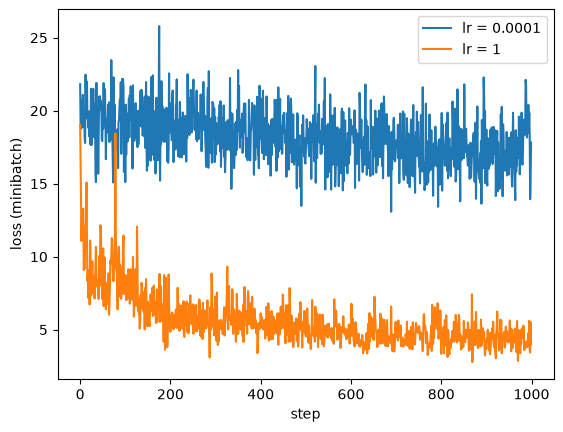

In [89]:
# Compare the two loss curves step by step
plt.plot(lossi_small, label='lr = 0.0001')
plt.plot(lossi_large, label='lr = 1')
plt.xlabel('step')
plt.ylabel('loss (minibatch)')
plt.legend()

### Comparing two fixed learning rates over time

Two separate training runs, each starting from fresh parameters and using a
single fixed learning rate for all 1,000 steps (minibatches of 32):

- **lr = 0.0001 (too small):** the loss stays high, around 15–20. It bounces
  because each step uses a different random minibatch, but there's no real
  downward trend: the steps are too small to make progress.
- **lr = 1 (too large):** the loss drops quickly at first, but the curve is
  spiky and the final result varies between runs: the steps overshoot the minimum.

So a good learning rate lies between these two extremes.

**Note:** this plot shows loss against *training step* for two fixed learning
rates. It's a different experiment from the learning rate search below, which
uses one run where the learning rate increases every step, and plots loss
against *learning rate*.

## Finding a good learning rate

One training run of 1,000 steps on a fresh model, where the learning rate
**increases every step**, from 0.001 to 1 (exponentially spaced). Plotting the
loss against the learning rate used at each step shows:
- **left (lr too small):** the loss barely decreases
- **middle (good lr):** the loss drops fastest
- **right (lr too large):** the loss becomes unstable and rises

We pick the learning rate at the bottom of the valley, just before it gets unstable.

In [94]:
# 1000 learning rates from 0.001 to 1, exponentially spaced
lre = torch.linspace(-3, 0, 1000)   # exponents: -3 ... 0
lrs = 10**lre                        # learning rates: 0.001 ... 1

In [95]:
# One run on a fresh model: step i uses learning rate lrs[i]
params_lrsearch = init_params()
lossi, lri = train(params_lrsearch, X_full, Y_full, steps=1000, batch_size=32, lrs=lrs, print_every=100)

step 0: lr 0.00100, loss 16.8085
step 100: lr 0.00200, loss 15.6626
step 200: lr 0.00399, loss 12.2475
step 300: lr 0.00796, loss 8.3004
step 400: lr 0.01589, loss 7.7953
step 500: lr 0.03173, loss 5.9342
step 600: lr 0.06336, loss 3.9476
step 700: lr 0.12650, loss 3.3524
step 800: lr 0.25258, loss 2.9948
step 900: lr 0.50432, loss 4.1273
final loss: 7.100492000579834


Text(0, 0.5, 'loss')

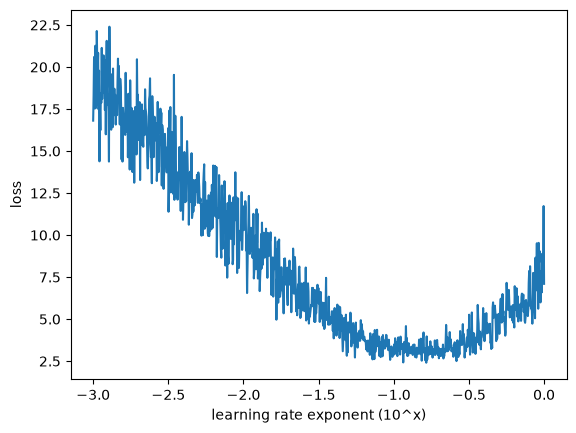

In [96]:
# Loss against the learning rate exponent used at each step
plt.plot(torch.tensor(lri).log10(), lossi)
plt.xlabel('learning rate exponent (10^x)')
plt.ylabel('loss')

**Result:** the loss drops fastest around an exponent of about [X],
so we use lr = 10^[X] ≈ [value].

In [97]:
params_best = init_params()

In [101]:
train(params_best, X_full, Y_full, steps=10000, lr=0.1, batch_size=32);
print(evaluate(params_best, X_full, Y_full))

step 0: lr 0.10000, loss 2.6942
step 1000: lr 0.10000, loss 2.3628
step 2000: lr 0.10000, loss 2.5418
step 3000: lr 0.10000, loss 2.3922
step 4000: lr 0.10000, loss 2.6557
step 5000: lr 0.10000, loss 2.3118
step 6000: lr 0.10000, loss 2.5403
step 7000: lr 0.10000, loss 2.2773
step 8000: lr 0.10000, loss 2.6089
step 9000: lr 0.10000, loss 2.3486
final loss: 2.400435447692871
2.392040967941284


In [104]:
print("small:     ", count_params(params_small))
print("minibatch: ", count_params(params_minibatch))
print("best pams: ", count_params(params_best))

small:      3481
minibatch:  3481
best pams:  3481


In [ ]:
# training, dev/validation, test split
# 80%, 10%, 10%

## Train / dev / test split (80% / 10% / 10%)

So far we've only measured the loss on data the model trained on, which can't
tell us whether it **generalizes** to new names or just memorized the old ones.
So we shuffle the names and split them into three sets, each with its own job:

| Split | Size | Used for |
|---|---|---|
| **Training** | 80% | Updating the parameters with gradient descent |
| **Dev / validation** | 10% | Choosing hyperparameters: hidden size, embedding size, learning rate, steps |
| **Test** | 10% | Measuring final performance, **only once**, at the very end |

**Comparing train and dev loss:**
- **Similar:** the model is *underfitting*, so it can afford to be bigger.
- **Train much lower:** the model is *overfitting*, memorizing instead of generalizing.

**Why a separate test set?** Every time we pick settings based on the dev loss,
we slightly fit the dev set too. The test set stays untouched, so it gives an
honest final number. Using it repeatedly would turn it into a second dev set.

**Why shuffle first?** `names.txt` might have some order to it, so shuffling
ensures each split is a fair, random sample of all names. The seed makes the
split reproducible.

In [105]:
import random

# Shuffle a copy of the names (so rerunning this cell always gives the same split),
# then split 80% / 10% / 10%
random.seed(42)
words_shuffled = words[:]          # a copy: the original `words` stays unchanged
random.shuffle(words_shuffled)

n1 = int(0.8 * len(words_shuffled))
n2 = int(0.9 * len(words_shuffled))

Xtr, Ytr = build_dataset(words_shuffled[:n1])       # 80% training
Xdev, Ydev = build_dataset(words_shuffled[n1:n2])   # 10% dev / validation
Xte, Yte = build_dataset(words_shuffled[n2:])       # 10% test

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [106]:
# Fresh model, trained ONLY on the training split
params_tr = init_params()

In [108]:
train(params_tr, Xtr, Ytr, steps=30000, lr=0.1, batch_size=32);

step 0: lr 0.10000, loss 2.2004
step 1000: lr 0.10000, loss 2.4298
step 2000: lr 0.10000, loss 2.5066
step 3000: lr 0.10000, loss 2.5398
step 4000: lr 0.10000, loss 2.5554
step 5000: lr 0.10000, loss 2.7092
step 6000: lr 0.10000, loss 2.5967
step 7000: lr 0.10000, loss 2.3173
step 8000: lr 0.10000, loss 2.2107
step 9000: lr 0.10000, loss 2.6422
step 10000: lr 0.10000, loss 2.3555
step 11000: lr 0.10000, loss 2.3712
step 12000: lr 0.10000, loss 2.4962
step 13000: lr 0.10000, loss 2.4045
step 14000: lr 0.10000, loss 2.1024
step 15000: lr 0.10000, loss 2.4368
step 16000: lr 0.10000, loss 3.0740
step 17000: lr 0.10000, loss 2.4728
step 18000: lr 0.10000, loss 2.3294
step 19000: lr 0.10000, loss 2.1294
step 20000: lr 0.10000, loss 2.4541
step 21000: lr 0.10000, loss 2.2012
step 22000: lr 0.10000, loss 2.1802
step 23000: lr 0.10000, loss 2.3431
step 24000: lr 0.10000, loss 2.4883
step 25000: lr 0.10000, loss 2.3093
step 26000: lr 0.10000, loss 2.9249
step 27000: lr 0.10000, loss 2.4265
step 

In [109]:
print("train loss:", evaluate(params_tr, Xtr, Ytr))
print("dev loss:  ", evaluate(params_tr, Xdev, Ydev))

train loss: 2.3713884353637695
dev loss:   2.3754663467407227


### Training on the training split

We shuffled a **copy** of the names (so rerunning the cell always gives the same
split) and built the three datasets with `build_dataset`. Then we trained a fresh
model **only on `Xtr`, `Ytr`**: 30,000 steps, minibatches of 32, lr = 0.1.

| | Loss |
|---|---|
| Train | 2.3714 |
| Dev | 2.3755 |

**Result:** the train and dev losses are almost identical (a gap of only 0.004),
so the model is **underfitting**: it isn't even able to memorize the training
set, so it does just as well on unseen names. With only 3,481 parameters
(2D embeddings, 100 hidden neurons), the model is too small to capture more
of the patterns in the data.

**Next:** make the model bigger, starting with the hidden layer, and check that
the dev loss improves without the gap between train and dev growing.

In [ ]:
# Bigger hidden layer: 300 neurons instead of 100
params_300 = init_params(n_hidden=300)
count_params(params_300)   # 10,281 (was 3,481 with 100 neurons)

10281

In [118]:
# Train on the training split only. Rerun to keep training (lossi holds only the latest run).
lossi, _ = train(params_300, Xtr, Ytr, steps=30000, lr=0.1, batch_size=32)

step 0: lr 0.10000, loss 2.3978
step 1000: lr 0.10000, loss 2.5455
step 2000: lr 0.10000, loss 2.4268
step 3000: lr 0.10000, loss 3.0338
step 4000: lr 0.10000, loss 2.3999
step 5000: lr 0.10000, loss 2.5678
step 6000: lr 0.10000, loss 2.1897
step 7000: lr 0.10000, loss 2.5097
step 8000: lr 0.10000, loss 2.5039
step 9000: lr 0.10000, loss 2.8292
step 10000: lr 0.10000, loss 2.8206
step 11000: lr 0.10000, loss 2.3436
step 12000: lr 0.10000, loss 2.7345
step 13000: lr 0.10000, loss 2.4461
step 14000: lr 0.10000, loss 2.3510
step 15000: lr 0.10000, loss 1.9942
step 16000: lr 0.10000, loss 2.5885
step 17000: lr 0.10000, loss 2.4547
step 18000: lr 0.10000, loss 2.5764
step 19000: lr 0.10000, loss 2.3125
step 20000: lr 0.10000, loss 2.4792
step 21000: lr 0.10000, loss 2.3709
step 22000: lr 0.10000, loss 2.1338
step 23000: lr 0.10000, loss 2.1538
step 24000: lr 0.10000, loss 2.0822
step 25000: lr 0.10000, loss 2.5714
step 26000: lr 0.10000, loss 2.5381
step 27000: lr 0.10000, loss 2.3017
step 

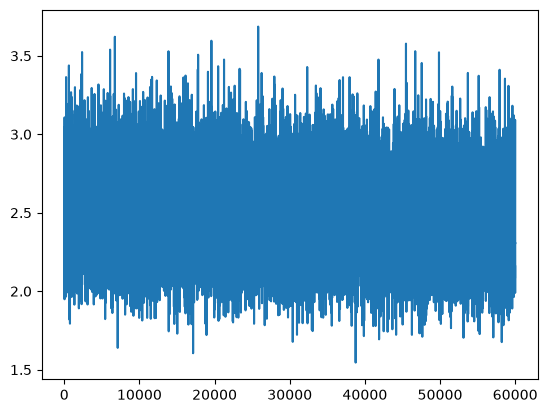

In [119]:
# Loss over the training steps (thick band = minibatch noise)
stepi = list(range(len(lossi)))
plt.plot(stepi, lossi)

In [120]:
# Compare: training set vs. unseen names
print("train loss:", evaluate(params_300, Xtr, Ytr))
print("dev loss:  ", evaluate(params_300, Xdev, Ydev))

train loss: 2.4698643684387207
dev loss:   2.477308988571167


In [121]:
# Continue training the same model with a smaller learning rate (decay):
# smaller steps let it settle closer to the minimum instead of bouncing around it.
# Rerun to keep training; don't rerun init_params, or training starts over.
lossi, _ = train(params_300, Xtr, Ytr, steps=30000, lr=0.05, batch_size=32)

step 0: lr 0.05000, loss 2.3096
step 1000: lr 0.05000, loss 2.3122
step 2000: lr 0.05000, loss 2.4669
step 3000: lr 0.05000, loss 2.3941
step 4000: lr 0.05000, loss 2.5284
step 5000: lr 0.05000, loss 2.3341
step 6000: lr 0.05000, loss 2.4595
step 7000: lr 0.05000, loss 2.6810
step 8000: lr 0.05000, loss 2.1806
step 9000: lr 0.05000, loss 2.5098
step 10000: lr 0.05000, loss 2.0952
step 11000: lr 0.05000, loss 2.3432
step 12000: lr 0.05000, loss 2.2832
step 13000: lr 0.05000, loss 2.3808
step 14000: lr 0.05000, loss 2.1952
step 15000: lr 0.05000, loss 2.3463
step 16000: lr 0.05000, loss 2.6820
step 17000: lr 0.05000, loss 2.3442
step 18000: lr 0.05000, loss 2.2463
step 19000: lr 0.05000, loss 2.2574
step 20000: lr 0.05000, loss 2.3610
step 21000: lr 0.05000, loss 2.0196
step 22000: lr 0.05000, loss 2.4850
step 23000: lr 0.05000, loss 2.1639
step 24000: lr 0.05000, loss 2.2455
step 25000: lr 0.05000, loss 2.2718
step 26000: lr 0.05000, loss 2.2392
step 27000: lr 0.05000, loss 2.7099
step 

In [122]:
# Results AFTER decay (30,000 more steps at lr = 0.05)
print("train loss:", evaluate(params_300, Xtr, Ytr))
print("dev loss:  ", evaluate(params_300, Xdev, Ydev))

train loss: 2.3280446529388428
dev loss:   2.3329555988311768


### Results: bigger hidden layer (300 neurons)

| Model | Train loss | Dev loss |
|---|---|---|
| 100 neurons (30k steps, lr 0.1) | 2.3714 | 2.3755 |
| 300 neurons, before decay (30k steps, lr 0.1) | 2.4699 | 2.4773 |
| 300 neurons, after decay (+30k steps, lr 0.05) | 2.3280 | 2.3330 |

The bigger model needed more training (and a lower learning rate) before its
extra capacity paid off. After decay, it beats the 100-neuron model by ~0.04.
Train and dev losses are still almost identical, so it's still **underfitting**.
Since tripling the hidden layer helped only a little, the bottleneck is likely
the **2D embeddings**: each character is squeezed into just 2 numbers.

In [123]:
# Round 3: continue training at lr = 0.05 (total so far: 90,000 steps)
lossi, _ = train(params_300, Xtr, Ytr, steps=30000, lr=0.05, batch_size=32)

step 0: lr 0.05000, loss 2.1060
step 1000: lr 0.05000, loss 2.5489
step 2000: lr 0.05000, loss 2.3974
step 3000: lr 0.05000, loss 2.4780
step 4000: lr 0.05000, loss 2.4058
step 5000: lr 0.05000, loss 2.1353
step 6000: lr 0.05000, loss 2.5596
step 7000: lr 0.05000, loss 2.2863
step 8000: lr 0.05000, loss 2.2697
step 9000: lr 0.05000, loss 2.4668
step 10000: lr 0.05000, loss 2.2690
step 11000: lr 0.05000, loss 2.5209
step 12000: lr 0.05000, loss 2.3656
step 13000: lr 0.05000, loss 2.5793
step 14000: lr 0.05000, loss 2.3735
step 15000: lr 0.05000, loss 2.4016
step 16000: lr 0.05000, loss 2.3978
step 17000: lr 0.05000, loss 2.2730
step 18000: lr 0.05000, loss 2.2575
step 19000: lr 0.05000, loss 2.3669
step 20000: lr 0.05000, loss 1.9242
step 21000: lr 0.05000, loss 2.1276
step 22000: lr 0.05000, loss 2.3497
step 23000: lr 0.05000, loss 2.4191
step 24000: lr 0.05000, loss 2.0958
step 25000: lr 0.05000, loss 2.5976
step 26000: lr 0.05000, loss 2.5576
step 27000: lr 0.05000, loss 2.1056
step 

In [124]:
# Results after round 3
print("train loss:", evaluate(params_300, Xtr, Ytr))
print("dev loss:  ", evaluate(params_300, Xdev, Ydev))

train loss: 2.3198065757751465
dev loss:   2.3324592113494873


In [125]:
# Round 4: final decay to lr = 0.01 (total so far: 120,000 steps)
lossi, _ = train(params_300, Xtr, Ytr, steps=30000, lr=0.01, batch_size=32)

step 0: lr 0.01000, loss 2.5102
step 1000: lr 0.01000, loss 1.8689
step 2000: lr 0.01000, loss 2.2603
step 3000: lr 0.01000, loss 2.2190
step 4000: lr 0.01000, loss 2.1287
step 5000: lr 0.01000, loss 1.8749
step 6000: lr 0.01000, loss 2.0944
step 7000: lr 0.01000, loss 2.4450
step 8000: lr 0.01000, loss 1.9700
step 9000: lr 0.01000, loss 2.5742
step 10000: lr 0.01000, loss 2.0794
step 11000: lr 0.01000, loss 2.2013
step 12000: lr 0.01000, loss 2.2508
step 13000: lr 0.01000, loss 2.0084
step 14000: lr 0.01000, loss 2.1375
step 15000: lr 0.01000, loss 2.4746
step 16000: lr 0.01000, loss 2.2691
step 17000: lr 0.01000, loss 2.6212
step 18000: lr 0.01000, loss 1.9820
step 19000: lr 0.01000, loss 2.0027
step 20000: lr 0.01000, loss 2.4157
step 21000: lr 0.01000, loss 2.4428
step 22000: lr 0.01000, loss 2.0349
step 23000: lr 0.01000, loss 2.5500
step 24000: lr 0.01000, loss 2.3076
step 25000: lr 0.01000, loss 1.9463
step 26000: lr 0.01000, loss 2.0599
step 27000: lr 0.01000, loss 1.9658
step 

In [126]:
# Results after round 4
print("train loss:", evaluate(params_300, Xtr, Ytr))
print("dev loss:  ", evaluate(params_300, Xdev, Ydev))

train loss: 2.231289863586426
dev loss:   2.2397806644439697


### Results: 300 hidden neurons, training in rounds

| Round | Steps (total) | lr | Train loss | Dev loss |
|---|---|---|---|---|
| 1 | 30k | 0.1 | 2.4699 | 2.4773 |
| 2 | 60k | 0.05 | 2.3280 | 2.3330 |
| 3 | 90k | 0.05 | 2.3198 | 2.3325 |
| 4 | 120k | 0.01 | 2.2313 | 2.2398 |

- Rounds 2–3: lr 0.05 helped at first, then plateaued (dev barely moved in round 3).
- Round 4: decaying to lr 0.01 gave the biggest single drop (~0.09). The model
  had been bouncing around the minimum, and smaller steps let it settle.
- Train and dev are still close (gap ~0.009), so the model is still **underfitting**.
- Dev loss 2.24: already close to the 2.2 target of exercise E01.

Next: bigger embeddings (2 → 10 dimensions), since the 2D embeddings are likely the bottleneck.

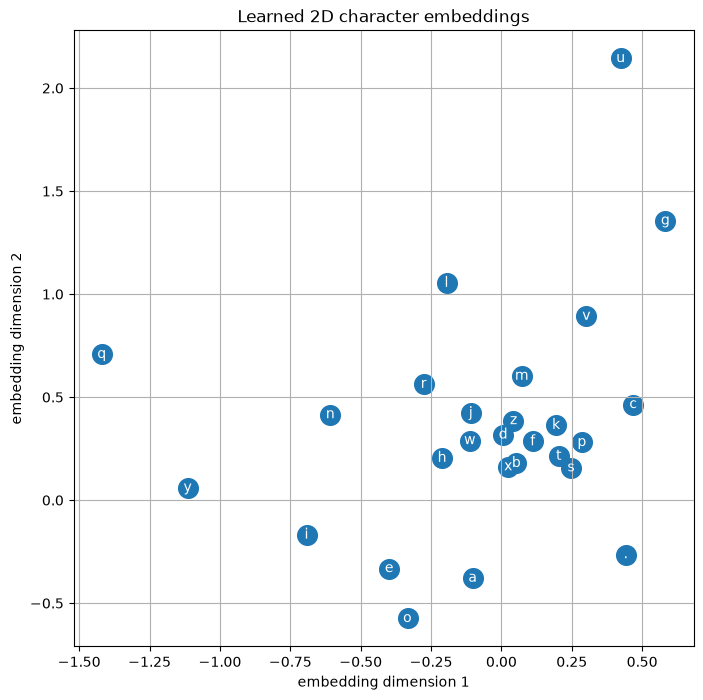

In [128]:
# Visualize the learned 2D embeddings: each character is a point
C = params_300[0].detach().cpu()   # the embedding table, (27, 2)

plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0], C[:, 1], s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color='white')
plt.xlabel('embedding dimension 1')
plt.ylabel('embedding dimension 2')
plt.title('Learned 2D character embeddings')
plt.grid('minor')

**Observations:** a, e, i, o cluster together: the network discovered vowels
on its own. u sits far apart (rarer, and used differently, e.g. after q).
y is on the vowel side, matching its vowel-like use in names. Most consonants
form a dense central cluster; rare q and the start/end token '.' sit alone.
With only 2 dimensions, the network has to squeeze all these distinctions
into one plane, which is the bottleneck we remove next with 10D embeddings.

In [134]:
print(count_params(init_params()))                           # 3,481: same as before
print(count_params(init_params(n_hidden=300)))               # 10,281: same as before
print(count_params(init_params(n_hidden=200, emb_dim=10)))   # 11,897: the new model

3481
10281
11897


In [137]:
params_emb10 = init_params(n_hidden=200, emb_dim=10)

In [138]:
lossi, _ = train(params_emb10, Xtr, Ytr, steps=50000, lr=0.1, batch_size=32, print_every=10000)

step 0: lr 0.10000, loss 25.0276
step 10000: lr 0.10000, loss 2.7430
step 20000: lr 0.10000, loss 2.0818
step 30000: lr 0.10000, loss 2.3064
step 40000: lr 0.10000, loss 1.9312
final loss: 2.6586098670959473


Text(0, 0.5, 'log10(loss)')

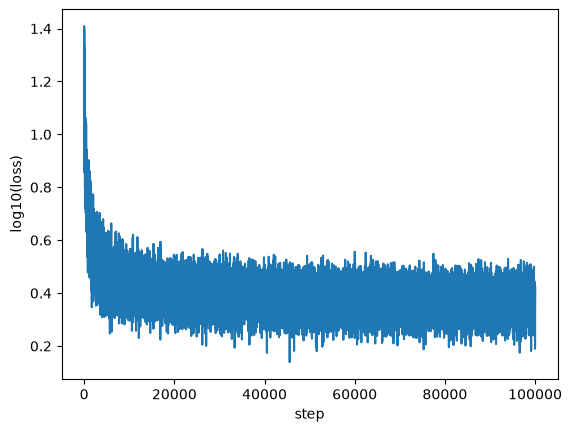

In [139]:
# Plot log10 of the loss, like Karpathy: easier to see the slow improvements later in training
plt.plot(torch.tensor(lossi).log10())
plt.xlabel('step')
plt.ylabel('log10(loss)')

In [140]:
print("train loss:", evaluate(params_emb10, Xtr, Ytr))
print("dev loss:  ", evaluate(params_emb10, Xdev, Ydev))

train loss: 2.324221134185791
dev loss:   2.3522112369537354


In [141]:
# Round 2: learning rate decay. Continue training the same model with lr = 0.01
# (smaller steps let it settle into the minimum). Don't rerun init_params.
lossi, _ = train(params_emb10, Xtr, Ytr, steps=50000, lr=0.01, batch_size=32, print_every=10000)

step 0: lr 0.01000, loss 2.6534
step 10000: lr 0.01000, loss 2.1794
step 20000: lr 0.01000, loss 1.7656
step 30000: lr 0.01000, loss 2.2213
step 40000: lr 0.01000, loss 1.8695
final loss: 2.068248987197876


In [142]:
# Results after round 2 (decay)
print("train loss:", evaluate(params_emb10, Xtr, Ytr))
print("dev loss:  ", evaluate(params_emb10, Xdev, Ydev))

train loss: 2.1724205017089844
dev loss:   2.2052414417266846


In [143]:
# Round 3:
lossi, _ = train(params_emb10, Xtr, Ytr, steps=50000, lr=0.01, batch_size=32, print_every=10000)

step 0: lr 0.01000, loss 2.1495
step 10000: lr 0.01000, loss 2.2375
step 20000: lr 0.01000, loss 2.6783
step 30000: lr 0.01000, loss 2.3125
step 40000: lr 0.01000, loss 2.3110
final loss: 2.114520311355591


In [144]:
# Results after round 3
print("train loss:", evaluate(params_emb10, Xtr, Ytr))
print("dev loss:  ", evaluate(params_emb10, Xdev, Ydev))

train loss: 2.1687819957733154
dev loss:   2.203136444091797


## Final run: 10D embeddings, 200 hidden neurons, 200k steps

One training run of 200,000 steps on a fresh model: lr = 0.1 for the first
100k steps, then lr = 0.01 for the last 100k (learning rate decay).

In [146]:
# Fresh model: 10-dimensional embeddings, 200 hidden neurons (11,897 parameters)
params_final = init_params(n_hidden=200, emb_dim=10)

In [147]:
# Learning rate schedule: 0.1 for the first 100k steps, then 0.01 for the next 100k
lrs = torch.tensor([0.1] * 100000 + [0.01] * 100000)

lossi, _ = train(params_final, Xtr, Ytr, steps=200000, batch_size=32, lrs=lrs, print_every=20000)

step 0: lr 0.10000, loss 29.6985
step 20000: lr 0.10000, loss 2.1840
step 40000: lr 0.10000, loss 2.5985
step 60000: lr 0.10000, loss 2.3818
step 80000: lr 0.10000, loss 1.9807
step 100000: lr 0.01000, loss 1.9413
step 120000: lr 0.01000, loss 2.0509
step 140000: lr 0.01000, loss 1.7999
step 160000: lr 0.01000, loss 1.8467
step 180000: lr 0.01000, loss 1.7570
final loss: 1.9223105907440186


Text(0, 0.5, 'log10(loss)')

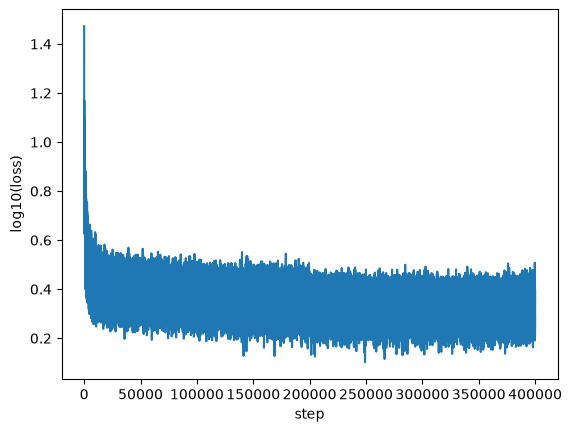

In [148]:
# Loss over all 200k steps (log scale); the drop at step 100k is the decay
plt.plot(torch.tensor(lossi).log10())
plt.xlabel('step')
plt.ylabel('log10(loss)')

In [149]:
print("train loss:", evaluate(params_final, Xtr, Ytr))
print("dev loss:  ", evaluate(params_final, Xdev, Ydev))

train loss: 2.1280837059020996
dev loss:   2.1697165966033936


### Results: final model (10D embeddings, 200 hidden neurons, 200k steps)

**Setup:** embeddings 2 → 10 dimensions, 200 hidden neurons (11,897 parameters),
200,000 steps with minibatches of 32: lr = 0.1 for the first 100k steps,
then lr = 0.01 for the last 100k.

| | Loss |
|---|---|
| Train | 2.1281 |
| Dev | 2.1697 |

**Comparison with earlier models:**

| Model | Parameters | Train | Dev |
|---|---|---|---|
| Bigram (lecture 2) | 729 | — | ~2.45 |
| 2D emb, 100 neurons | 3,481 | 2.3714 | 2.3755 |
| 2D emb, 300 neurons (120k steps, decay) | 10,281 | 2.2313 | 2.2398 |
| **10D emb, 200 neurons (200k steps, decay)** | **11,897** | **2.1281** | **2.1697** |

**Observations:**
- With a similar number of

In [150]:
def sample(parameters, n=20, seed=2147483647 + 10):
    """Generate n names from the model, one character at a time."""
    C, W1, b1, W2, b2 = parameters
    g = torch.Generator().manual_seed(seed)
    names = []
    with torch.no_grad():                            # no gradients needed, just generating
        for _ in range(n):
            out = []
            context = [0] * block_size               # start with '...'
            while True:
                # forward pass on the current context (a batch of 1 example)
                emb = C[torch.tensor([context], device=C.device)]   # (1, block_size, emb_dim)
                h = torch.tanh(emb.view(1, -1) @ W1 + b1)            # (1, n_hidden)
                logits = h @ W2 + b2                                 # (1, 27)
                probs = F.softmax(logits, dim=1).cpu()               # probabilities for the next character
                # sample the next character
                ix = torch.multinomial(probs, num_samples=1, generator=g).item()
                context = context[1:] + [ix]         # slide the window
                out.append(ix)
                if ix == 0:                          # sampled '.', so the name is finished
                    break
            names.append(''.join(itos[i] for i in out))
    return names

In [151]:
for name in sample(params_final):
    print(name)

carmahzabelle.
khy.
myliathty.
halaysa.
jazhuen.
den.
art.
kaeli.
nellara.
chaiir.
kaleigh.
ham.
joce.
quintis.
lilah.
jadbi.
wazeloniearynix.
kaelyighan.
edde.
oia.


## Sampling from the model

To generate a name, start with the context `...` and repeat:
1. Run the model on the current 3-character context to get 27 logits.
2. Softmax turns them into probabilities for the next character.
3. Sample one character from those probabilities (`torch.multinomial`).
4. Slide the context window: drop the oldest character, add the new one.
5. Stop when the model samples `.` (the end-of-name token).

**Example names from the final model:**
kaleigh.
ham.
joce.
quintis.
lilah

**Observations:** compared with the bigram model (e.g. "fidon.", "mor."),
the names sound much more name-like, because the model now sees 3 characters
of context instead of 1. They still aren't perfect: the model can't plan a
whole name, only predict the next character from the last three.